In [ ]:
import os
import glob
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from scipy.ndimage import zoom

import torch
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchsummary import summary
import torch.optim as optim

from lib.dataset.dataloader import SICDataLoader, _load_sic, _load_amsr2, _load_pair, _extract_statistics_worker
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm


### Data exploration

In [3]:
# dfs = []
# for year in range(2014, 2025):
#     csv_path = f'/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_{year}.csv'
#     if not os.path.exists(csv_path): #2020, 2021, 2022
#         continue

#     df = pd.read_csv(csv_path)
#     dfs.append(df)

# df_stats = pd.concat(dfs, ignore_index=True)
# df_stats.to_csv('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/sic_amsr2_metadata_stats_all_year.csv', index=False)


In [7]:
sic_loader = SICDataLoader(
    data_dirs=['/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2','/dmidata/projects/asip-cms/reproc'],
    shuffle=False,
    date_pattern=r'(\d{8})[T]\d{6}',
    years = [2014]
)


Manually loading files

In [8]:
amsr2_file = sic_loader.get_matched_pairs_info()[2]['amsr2_files'][0]
# amsr2_file = "\\\\?\\" + os.path.abspath(Path(amsr2_file).as_posix())

sic_file = sic_loader.get_matched_pairs_info()[2]['sic_files'][0]
# sic_file = "\\\\?\\" + os.path.abspath(Path(sic_file).as_posix())

print(f"AMSR2 file: {amsr2_file}")
print(f"SIC file: {sic_file}")

AMSR2 file: /dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2014/11/02/AMSR2_S1A_EW_GRDM_1SDH_20141102T211238_20141102T211338_003108_003909_97DC.nc
SIC file: /dmidata/projects/asip-cms/reproc/2014/11/02/S1A_EW_GRDM_1SDH_20141102T211238_20141102T211338_003108_003909_97DC_SIC.tiff


In [9]:
ds = xr.load_dataset(amsr2_file)
print(ds)
da = rioxarray.open_rasterio(sic_file)
print(da)
print(da.rio.crs)

<xarray.Dataset> Size: 5MB
Dimensions:             (dim_0: 199, dim_1: 207)
Dimensions without coordinates: dim_0, dim_1
Data variables: (12/15)
    btemp_6.9h          (dim_0, dim_1) float64 330kB 236.1 236.1 ... 234.7 234.6
    btemp_6.9v          (dim_0, dim_1) float64 330kB 255.7 255.7 ... 250.6 250.6
    btemp_7.3h          (dim_0, dim_1) float64 330kB 237.0 237.0 ... 235.4 235.1
    btemp_7.3v          (dim_0, dim_1) float64 330kB 256.4 256.4 ... 251.6 251.6
    btemp_10.7h         (dim_0, dim_1) float64 330kB 239.1 239.1 ... 233.7 233.2
    btemp_10.7v         (dim_0, dim_1) float64 330kB 256.3 256.3 ... 253.7 253.6
    ...                  ...
    btemp_23.8v         (dim_0, dim_1) float64 330kB 252.5 252.6 ... 254.8 254.7
    btemp_36.5h         (dim_0, dim_1) float64 330kB 241.0 241.0 ... 241.8 241.4
    btemp_36.5v         (dim_0, dim_1) float64 330kB 247.9 247.8 ... 253.0 253.0
    btemp_89.0h         (dim_0, dim_1) float64 330kB 222.4 220.1 ... 237.2 238.0
    btemp_89.0v 

In [13]:
ds_amsr = _load_amsr2(amsr2_file, sic_loader.date_pattern)
print(ds_amsr)
ds_sic = _load_sic(sic_file, sic_loader.date_pattern)
nodata_mask = (ds_sic['band']['band_1'] == 255) | np.isnan(ds_sic['band']['band_1'])
ds_sic['band']['band_1'] = np.where(nodata_mask, np.nan, ds_sic['band']['band_1'])
print(ds_sic)

{'time': '20141102T211238', 'num_swaths': 999, 'file_path': '/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2014/11/02/AMSR2_S1A_EW_GRDM_1SDH_20141102T211238_20141102T211338_003108_003909_97DC.nc', 'type': 'amsr2', 'error': "[Errno -101] NetCDF: HDF error: '/dmidata/projects/asip-cms/tests/new_input_ncs/AMSR2/2014/11/02/AMSR2_S1A_EW_GRDM_1SDH_20141102T211238_20141102T211338_003108_003909_97DC.nc'"}
{'time': '20141102T211238', 'band': {'band_1': array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]]), 'band_2': array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 25

In [ ]:
# ds_amsr = xr.load_dataset(amsr2_file, engine='netcdf4')

In [ ]:
for var in ds_amsr:
    print(f"AMSR2 variable: {var}")

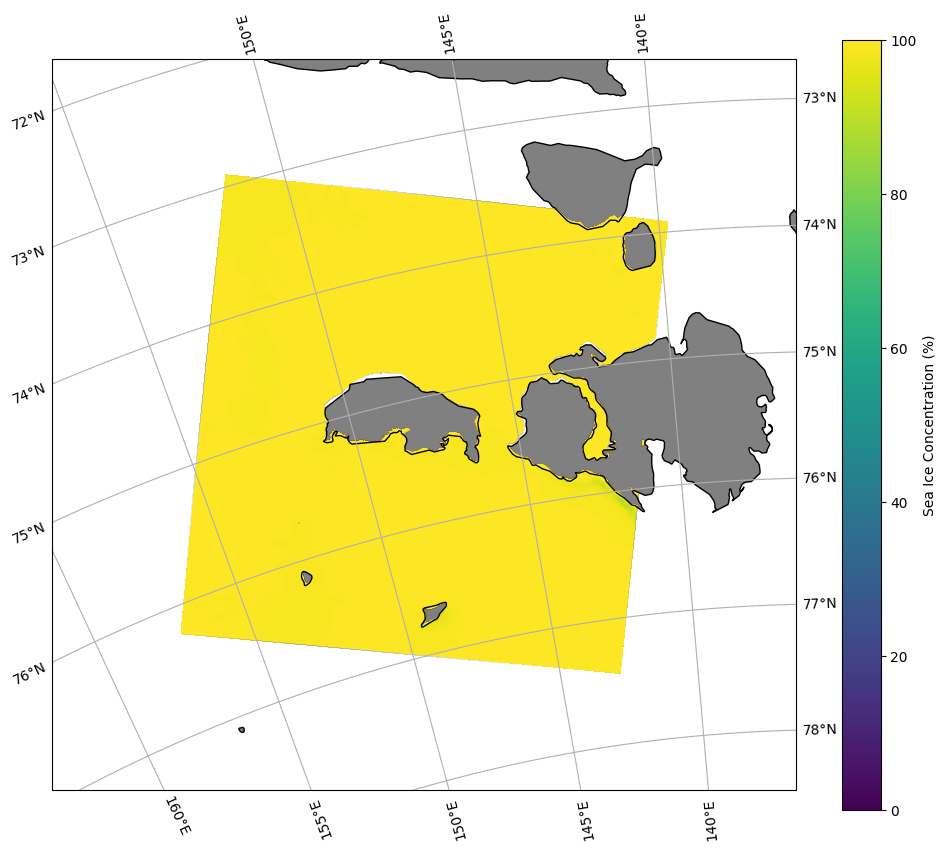

In [9]:
data_crs = ccrs.Stereographic(
    central_latitude=90, 
    central_longitude=-45, 
    true_scale_latitude=ds_sic['standard_parallel']
)

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

minx, miny, maxx, maxy = ds_sic['bbox']
ax.set_extent([minx - 100000, maxx + 100000, miny - 100000, maxy + 100000], crs=data_crs)

# Add Geography
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

ax.imshow(
    ds_sic['band']['band_1'] ,
    transform=data_crs,
    extent=(minx, maxx, miny, maxy),
    cmap='viridis',
    vmin=0, vmax=100, 
    origin='upper',
    zorder=1
)
# plot_data.plot.imshow(
#     ax=ax,
#     transform=data_crs,
#     x='x', y='y',
#     cmap='Blues_r',
#     vmin=0, vmax=100, 
#     cbar_kwargs={'label': 'Sea Ice Concentration (%)'}
# )

ax.add_feature(cfeature.LAND, facecolor='gray', zorder=0)
cb = fig.colorbar(ax.images[0], ax=ax, orientation='vertical')
cb.set_label('Sea Ice Concentration (%)')

# plt.title("Fram Strait / Greenland Sea - Sea Ice (EPSG:3411)")
plt.show()

In [ ]:
print(ds_amsr['frequencies']['btemp_89.0h'].shape)
print(ds_sic['band']['band_1'].shape)

(199, 207)
(5501, 5635)


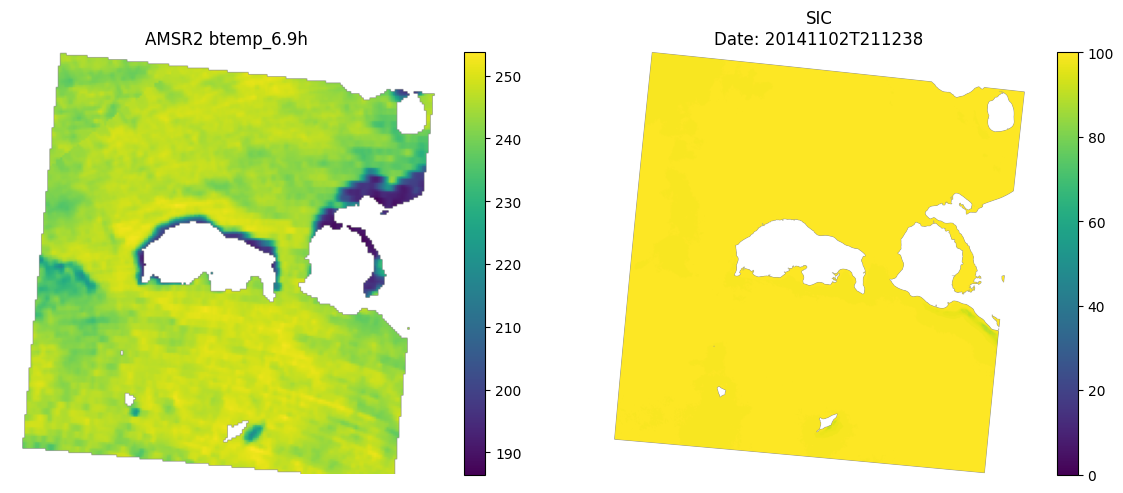

In [34]:
amsr_data = ds_amsr['frequencies']['btemp_89.0v'][::-1,:]
sic_data  = ds_sic['band']['band_2']

extent = [ds_sic['bbox'][0], ds_sic['bbox'][2], ds_sic['bbox'][1], ds_sic['bbox'][3]]


zoom_factors = (sic_data.shape[0] // amsr_data.shape[0],
                sic_data.shape[1] // amsr_data.shape[1])
# sic_downsampled = zoom(sic_data, zoom_factors, order=1)

from skimage.transform import downscale_local_mean
# # Mask: nodata is 255 or nan
nodata_mask = (sic_data == 255) | np.isnan(sic_data)
nodata_mask = downscale_local_mean(nodata_mask.astype(float), zoom_factors).astype(bool)
nodata_mask = nodata_mask[:amsr_data.shape[0], :amsr_data.shape[1]] 
amsr_masked = np.where(nodata_mask, np.nan, amsr_data)
# sic_masked  = np.where(nodata_mask, np.nan, sic_data)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': data_crs})

im0 = axes[0].imshow(amsr_masked, cmap='viridis', extent=extent, transform=data_crs)
# axes[0].add_feature(cfeature.LAND, facecolor='gray', zorder=0)
# axes[0].coastlines(resolution='10m', color='black', linewidth=1)
axes[0].set_title('AMSR2 btemp_6.9h')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(ds_sic['band']['band_1'], cmap='viridis', vmin=0, vmax=100, extent=extent, transform=data_crs)
axes[1].set_title(f"SIC\nDate: {ds_sic['time']}")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Sample data plots

In [13]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import ast

TRAINING_INDEX_CSV = '/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/training_index.csv'

In [14]:
df = pd.read_csv(TRAINING_INDEX_CSV)

# Use the split column written by add_split_column() in preprocess.py
# If the column does not exist yet, create it here with the same seed
if 'split' not in df.columns:
    from sklearn.model_selection import train_test_split
    train_idx, val_idx = train_test_split(df.index.tolist(), test_size=0.2, random_state=42, shuffle=True)
    df['split'] = 'train'
    df.loc[val_idx, 'split'] = 'val'
    print('split column created on the fly (not yet saved to CSV)')

df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val   = df[df['split'] == 'val'].reset_index(drop=True)

print(f'Total  : {len(df)}')
print(f'Train  : {len(df_train)}')
print(f'Val    : {len(df_val)}')


Total  : 50000
Train  : 40000
Val    : 10000


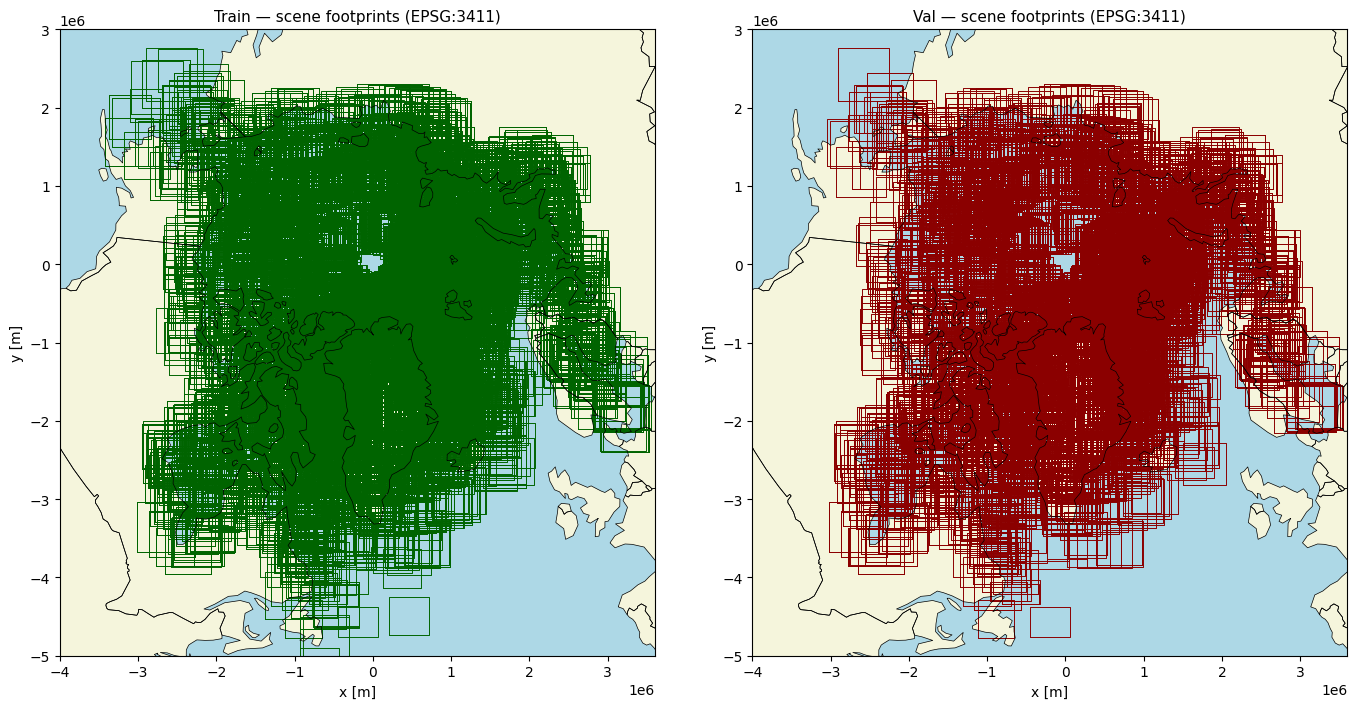

In [15]:
import geopandas as gpd
from shapely.geometry import box
import ast

world = gpd.read_file('/dmidata/projects/asip-cms/code/sentinel1_download/flood_data/ne_110m_admin_0_countries.shp')
world = world[world['SOVEREIGNT'] != 'Antarctica']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, dfs, title, color in zip(
    axes,
    [df_train, df_val],
    ['Train', 'Val'],
    ['darkgreen', 'darkred'],
):
    gdf = gpd.GeoDataFrame(
        dfs.copy(),
        geometry=dfs['bbox'].apply(lambda s: box(*ast.literal_eval(s))),
        crs='EPSG:3411',
    )

    ax.set_facecolor('lightblue')
    world.to_crs(epsg=3411).plot(ax=ax, color='beige')
    world.boundary.to_crs(epsg=3411).plot(ax=ax, color='black', linewidth=0.5, zorder=3)
    gdf.boundary.to_crs(epsg=3411).plot(ax=ax, color=color, linewidth=0.7, zorder=2)

    ax.set_xlim(-4e6, 3.6e6)
    ax.set_ylim(-5e6, 3e6)
    ax.set_title(f'{title} — scene footprints (EPSG:3411)', fontsize=11)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')

plt.tight_layout()
plt.show()

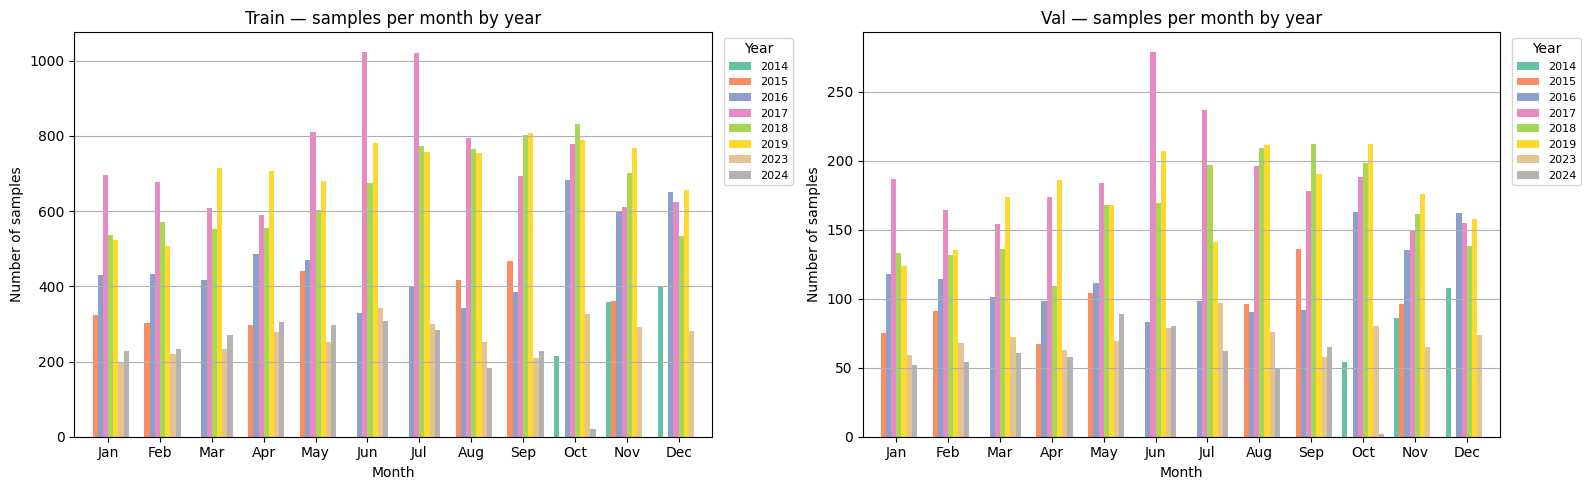

In [16]:
# Sample counts per month and year
# seasonal and temporal coverage check
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dfs, title in zip(axes, [df_train, df_val], ['Train', 'Val']):
    dfs.groupby(['year', 'month']).size().unstack(level=0).plot(
        kind='bar', ax=ax, colormap='Set2', width=0.8
    )
    ax.grid(axis='y')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of samples')
    ax.set_title(f'{title} — samples per month by year')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
    ax.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


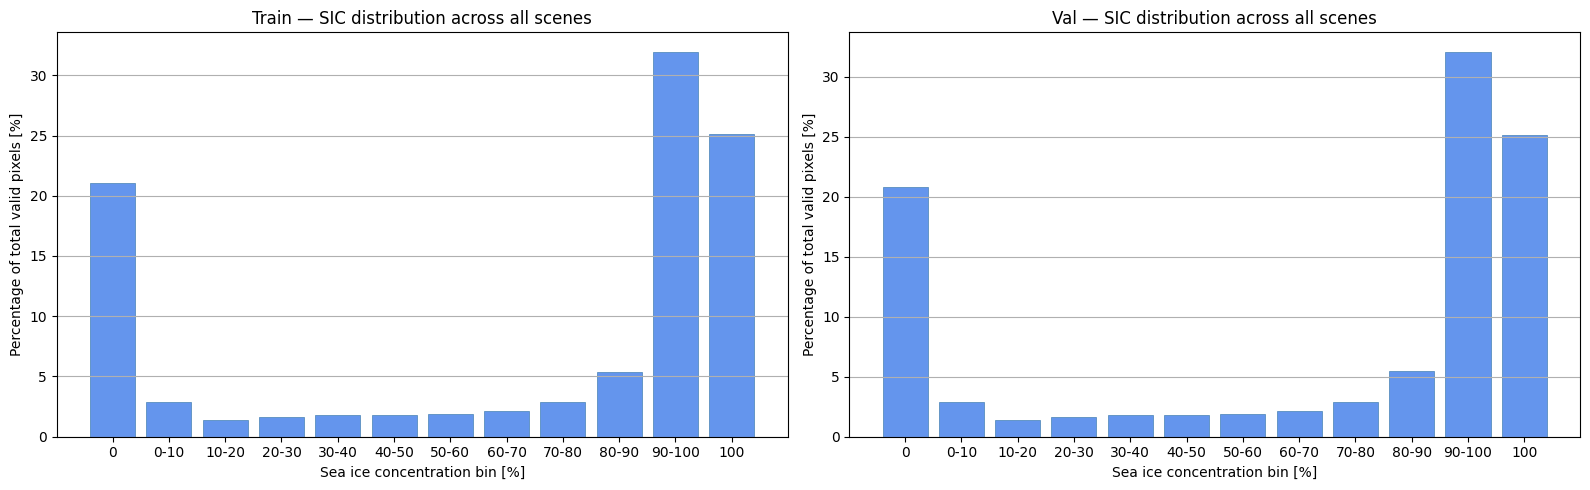

In [17]:
# SIC pixel distribution
# class balance check between splits
bins = ['val_0', '0-10', '10-20', '20-30', '30-40', '40-50',
        '50-60', '60-70', '70-80', '80-90', '90-100', 'val_100']
xlabels = ['0', '0-10', '10-20', '20-30', '30-40', '40-50',
           '50-60', '60-70', '70-80', '80-90', '90-100', '100']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, dfs, title in zip(axes, [df_train, df_val], ['Train', 'Val']):
    bin_totals = dfs[bins].sum()
    bin_pct    = bin_totals / bin_totals.sum() * 100
    ax.bar(range(len(bins)), bin_pct, color='cornflowerblue', edgecolor='steelblue', linewidth=0.5)
    ax.set_xticks(range(len(bins)))
    ax.set_xticklabels(xlabels, rotation=0)
    ax.set_xlabel('Sea ice concentration bin [%]')
    ax.set_ylabel('Percentage of total valid pixels [%]')
    ax.set_title(f'{title} — SIC distribution across all scenes')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()


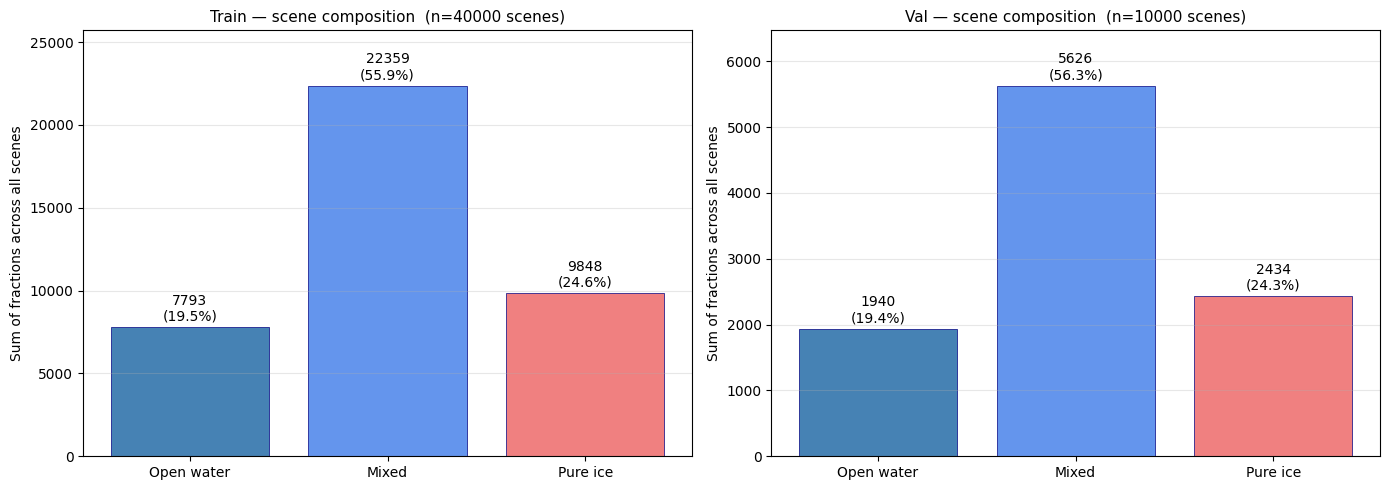

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dfs, title in zip(axes, [df_train, df_val], ['Train', 'Val']):
    pure_water = dfs['frac_open_water'].sum()
    mixed      = dfs['frac_mixed'].sum()
    pure_ice   = dfs['frac_ice100'].sum()

    counts = [pure_water, mixed, pure_ice]
    labels = ['Open water', 'Mixed', 'Pure ice']
    colors = ['steelblue', 'cornflowerblue', 'lightcoral']

    total = dfs['frac_open_water'].sum() + dfs['frac_mixed'].sum() + dfs['frac_ice100'].sum()

    bars = ax.bar(labels, counts, color=colors, edgecolor='navy', linewidth=0.5)

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f'{count:.0f}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10,
        )

    ax.set_title(f'{title} — scene composition  (n={len(dfs)} scenes)', fontsize=11)
    ax.set_ylabel('Sum of fractions across all scenes')
    ax.set_ylim(0, max(counts) * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

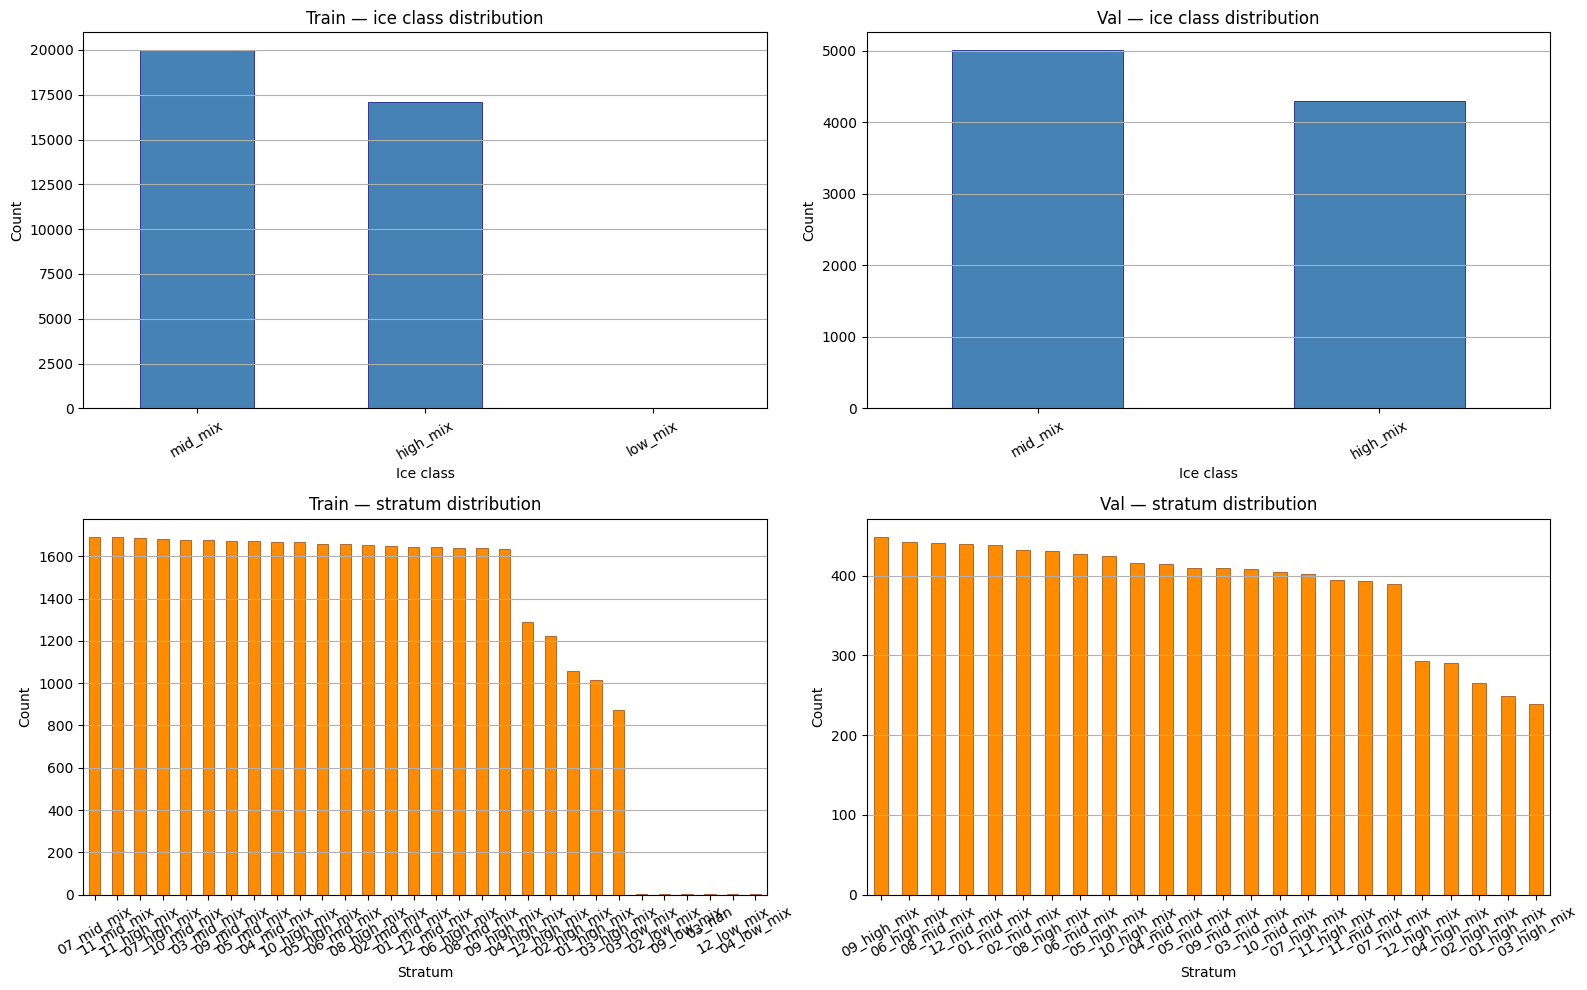

In [19]:
# Ice class and stratum distribution
# sampling tier distribution check
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (dfs, title) in enumerate([(df_train, 'Train'), (df_val, 'Val')]):
    # ice class
    ax = axes[0, col]
    dfs['ice_class'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='navy', linewidth=0.5)
    ax.set_title(f'{title} — ice class distribution')
    ax.set_xlabel('Ice class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y')

    # stratum
    ax = axes[1, col]
    dfs['stratum'].value_counts().plot(kind='bar', ax=ax, color='darkorange', edgecolor='saddlebrown', linewidth=0.5)
    ax.set_title(f'{title} — stratum distribution')
    ax.set_xlabel('Stratum')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()


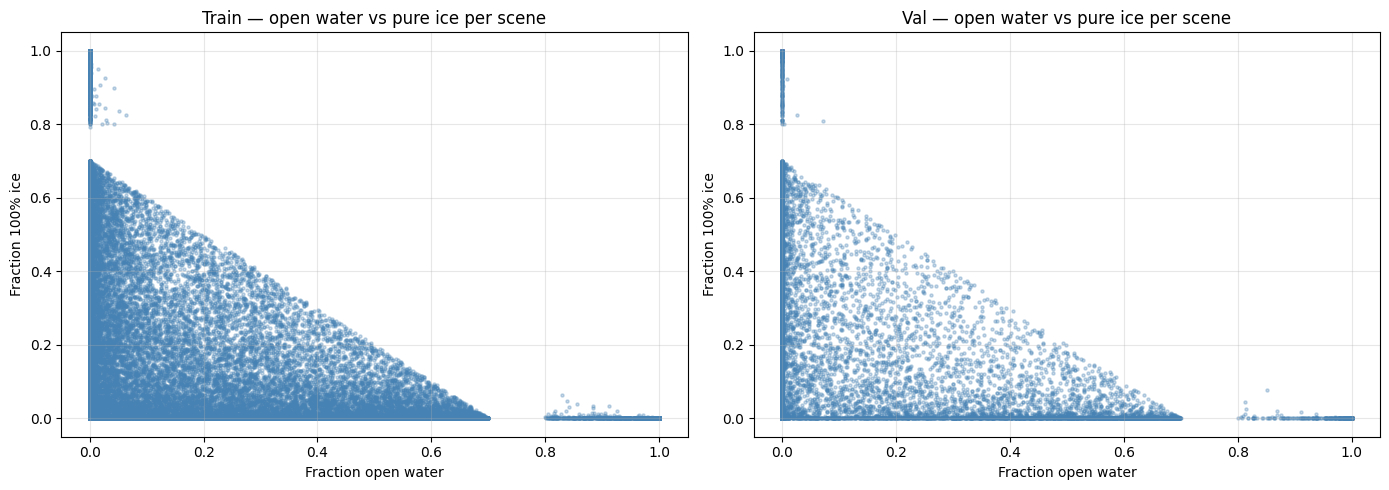

In [20]:
# Open water and pure ice fractions
# scene type composition check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dfs, title in zip(axes, [df_train, df_val], ['Train', 'Val']):
    ax.scatter(dfs['frac_open_water'], dfs['frac_ice100'],
               alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel('Fraction open water')
    ax.set_ylabel('Fraction 100% ice')
    ax.set_title(f'{title} — open water vs pure ice per scene')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


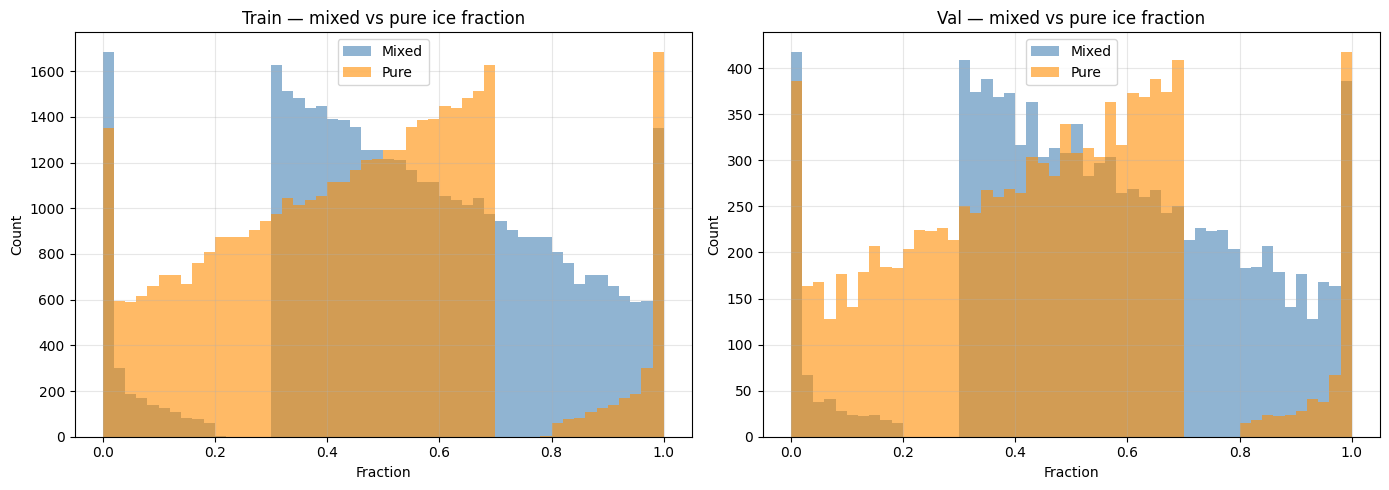

In [21]:
# Mixed vs pure fraction distribution
# difficulty distribution check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dfs, title in zip(axes, [df_train, df_val], ['Train', 'Val']):
    ax.hist(dfs['frac_mixed'], bins=50, alpha=0.6, label='Mixed', color='steelblue')
    ax.hist(dfs['frac_pure'],  bins=50, alpha=0.6, label='Pure',  color='darkorange')
    ax.set_xlabel('Fraction')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} — mixed vs pure ice fraction')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
df = pd.read_csv('/dmidata/users/nili/Master/Master-thesis---Super-resolution-sea-ice-concentration-using-generative-AI/training_index.csv')

# Check the frac_mixed distribution per stratum
print(df.groupby('stratum')['frac_mixed'].describe())

# Check where the gap is
gap = df[(df['frac_mixed'] > 0.2) & (df['frac_mixed'] < 0.3)]
print(f"\nScenes with frac_mixed 0.2-0.3: {len(gap)}")
print(gap['stratum'].value_counts())

              count      mean       std       min       25%       50%  \
stratum                                                                 
01_high_mix  1262.0  0.760294  0.113005  0.600367  0.664012  0.742805   
01_mid_mix   2083.0  0.432394  0.086432  0.300281  0.358710  0.425680   
02_high_mix  1324.0  0.759050  0.110746  0.600027  0.662262  0.739564   
02_low_mix      2.0  0.197743  0.015054  0.187098  0.192421  0.197743   
02_mid_mix   2082.0  0.432273  0.084867  0.300101  0.356605  0.424689   
03_high_mix  1112.0  0.751476  0.105430  0.600100  0.664277  0.730064   
03_low_mix      3.0  0.097720  0.045033  0.069107  0.071766  0.074424   
03_mid_mix   2083.0  0.427791  0.084120  0.300101  0.354855  0.417449   
03_nan          1.0  0.000000       NaN  0.000000  0.000000  0.000000   
04_high_mix  1579.0  0.736840  0.101805  0.600038  0.651943  0.714493   
04_low_mix      1.0  0.074122       NaN  0.074122  0.074122  0.074122   
04_mid_mix   2083.0  0.431940  0.086096  0.300040  